In [1]:
%load_ext dotenv
%dotenv 
import os
import sys
sys.path.append(os.getenv('SRC_DIR'))
from utils.logger import get_logger
_logs = get_logger(__name__)

In [2]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import os
from glob import glob

In [3]:
ft_dir = os.getenv("FEATURES_DATA")
ft_glob = glob(os.path.join(ft_dir, '**/*.parquet'), 
               recursive = True)
df = dd.read_parquet(ft_glob).compute().reset_index()

# Sampling in Python

+ There are different packages that allow sampling.
+ A practical approach is to use pandas/Dask sampling methods.

## Random Sampling

+ Sample n rows from a dataframe with [`df.sample()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html).

```
DataFrame.sample(
    n=None, frac=None, replace=False, weights=None, 
    random_state=None, axis=None, ignore_index=False
    )
```

In [4]:
df

,ticker,Date,Open,High,Low,Close,Adj Close,Volume,source,Year,Close_lag_1
0,A,1999-11-18,32.546494,35.765381,28.612303,31.473534,27.068665,62546300.0,A.csv,1999,NaN
1,A,1999-11-19,30.713520,30.758226,28.478184,28.880543,24.838577,15234100.0,A.csv,1999,31.473534
2,A,1999-11-22,29.551144,31.473534,28.657009,31.473534,27.068665,6577800.0,A.csv,1999,28.880543
3,A,1999-11-23,30.400572,31.205294,28.612303,28.612303,24.607880,5975600.0,A.csv,1999,31.473534
4,A,1999-11-24,28.701717,29.998211,28.612303,29.372318,25.261524,4843200.0,A.csv,1999,28.612303
...,...,...,...,...,...,...,...,...,...,...,...
338256,ZEUS,2004-06-28,19.270000,19.520000,18.280001,19.000000,17.401590,256400.0,ZEUS.csv,2004,19.219999
338257,ZEUS,2004-06-29,19.200001,19.900000,19.100000,19.900000,18.225878,123300.0,ZEUS.csv,2004,19.000000
338258,ZEUS,2004-06-30,19.940001,20.420000,19.900000,20.420000,18.702133,186000.0,ZEUS.csv,2004,19.900000
338259,ZEUS,2004-07-01,20.400000,20.570000,19.219999,19.250000,17.630552,266500.0,ZEUS.csv,2004,20.420000


In [6]:
df.sample(n = 25)

,ticker,Date,Open,High,Low,Close,Adj Close,Volume,source,Year,Close_lag_1
30366,AMSWA,1999-08-31,3.625000,3.625000,3.437500,3.437500,1.528618,8600.0,AMSWA.csv,1999,3.750000
55019,AXP,2019-08-02,123.919998,124.910004,123.080002,124.309998,122.726906,3268800.0,AXP.csv,2019,124.089996
54715,AXP,2018-05-17,100.650002,101.639999,100.300003,101.220001,98.155472,2876100.0,AXP.csv,2018,100.589996
111047,CVCY,2014-05-02,11.380000,11.530000,11.220000,11.350000,10.254230,18200.0,CVCY.csv,2014,11.300000
127000,CVR,1994-06-09,14.187500,14.187500,14.000000,14.000000,4.854703,600.0,CVR.csv,1994,14.125000
254322,PNR,1979-02-01,2.252630,2.322588,2.252630,2.252630,0.245046,82700.0,PNR.csv,1979,2.210656
211848,LIVE,2019-06-24,6.980000,7.250000,6.980000,7.080000,7.080000,2600.0,LIVE.csv,2019,7.030000
36421,AOSL,2012-12-12,8.810000,8.810000,8.720000,8.720000,8.720000,48800.0,AOSL.csv,2012,8.810000
122027,CVR,2015-12-31,23.120001,23.330000,23.030001,23.180000,20.576260,1900.0,CVR.csv,2015,23.049999
212470,LIVE,2003-10-07,376.000000,402.000000,368.000000,386.000000,372.562408,1600.0,LIVE.csv,2003,368.000000


In [7]:
import random
random.seed(42)
sample_tickers = random.sample(df['ticker'].unique().tolist(), 30)
df = df[df['ticker'].isin(sample_tickers)]
simple_sample_dt = df.sample(frac = 0.1)
simple_sample_dt.shape, df.shape

((14872, 11), (148719, 11))

Look at the distribution of tickers.

<Axes: xlabel='ticker'>

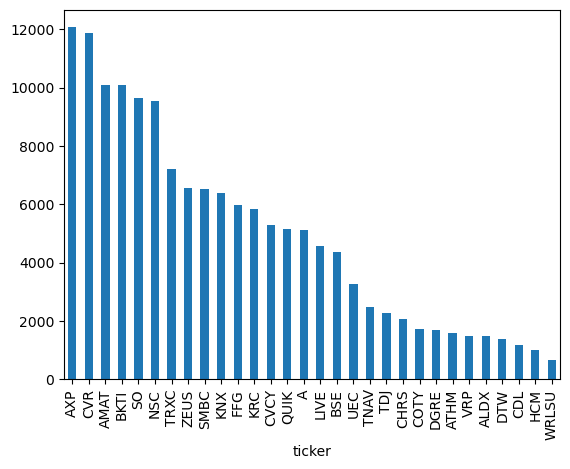

In [8]:
df['ticker'].value_counts().plot(kind='bar')

<Axes: xlabel='ticker'>

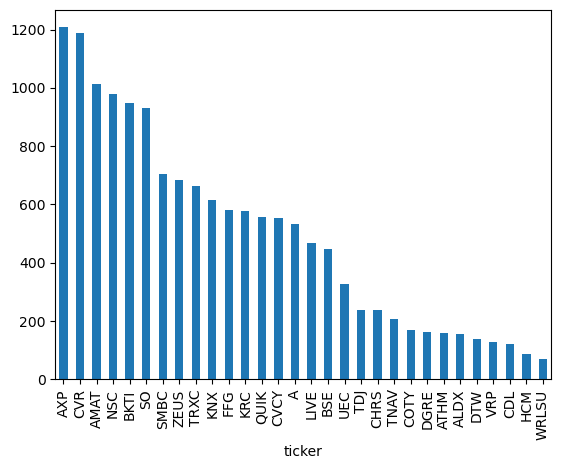

In [9]:
simple_sample_dt['ticker'].value_counts().plot(kind='bar')

## Stratified Sampling

+ Use `groupby()` and `.sample()` for stratified sampling.

<Axes: xlabel='ticker'>

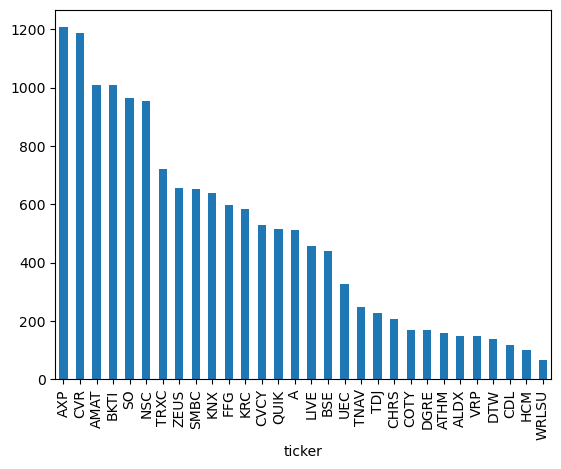

In [10]:
strat_sample_dt = df.groupby(['ticker']).sample(frac = 0.1)
strat_sample_dt['ticker'].value_counts().plot(kind='bar')

# Sampling in Dask

+ Stratified sampling in `dask` can be achieved with `groupby().apply()` and a lambda function.

/var/folders/xs/w60hxvws49nbndc6b_91qs4w0000gn/T/ipykernel_12982/1783207470.py:2: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  strat_sample_dd = (dd_dt


<Axes: xlabel='ticker'>

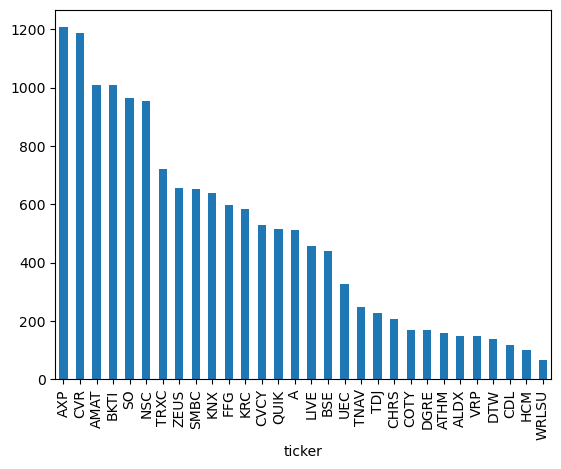

In [11]:
dd_dt = dd.read_parquet(ft_glob)
strat_sample_dd = (dd_dt
                      .groupby('ticker', group_keys=False)
                      .apply(lambda x: x.sample(frac = 0.1))
                      .compute()
                      .reset_index())
strat_sample_dd[strat_sample_dd['ticker'].isin(sample_tickers)]['ticker'].value_counts().plot(kind='bar')